## DBSCAN Clutering

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_circles

In [2]:

X, y = make_circles(n_samples=750, factor=0.3, noise=0.1)

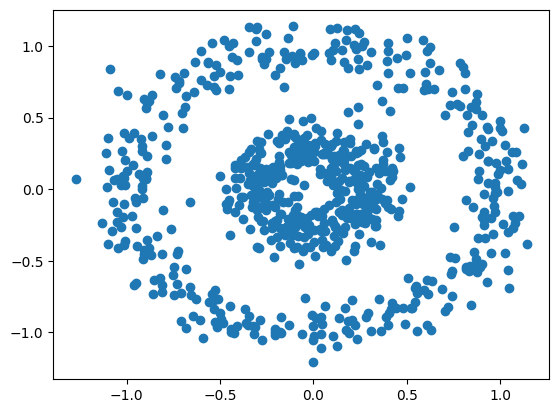

In [3]:
plt.scatter(X[:,0],X[:,1])

In [4]:
from sklearn.cluster import DBSCAN

In [5]:
dbcan=DBSCAN(eps=0.1)

In [6]:
dbcan.fit_predict(X)

array([ 0,  1,  0,  1,  1,  2,  2,  1,  1,  1,  1,  3,  1,  1, -1,  1,  0,
       -1,  1,  2,  2,  1, -1,  2,  1, -1,  1,  1,  4,  5,  1,  2,  5,  1,
        1,  1,  1,  1,  0,  2,  2,  1,  6,  5,  1,  5,  0,  1,  1, -1,  5,
        3,  2,  1,  1,  6,  3,  1,  1, -1,  1,  1,  2,  1,  2, -1,  1,  2,
        2,  2,  0,  1,  2,  1,  1,  1,  1,  2,  4, -1,  4,  6,  1,  1,  1,
        2,  1,  1,  1,  1,  1,  1,  7,  1,  1,  1,  1,  1,  1,  2,  2,  6,
        1,  1,  6,  1,  1,  1,  1,  5,  1,  2,  5,  4,  2,  1,  3,  1,  1,
        5,  2,  1,  5,  6,  1,  1,  1,  1,  1,  0,  2,  2,  1,  2,  0,  1,
        1,  1,  1,  1,  1,  1,  6,  1,  6,  1,  1,  1,  1,  1,  1,  0,  1,
        2,  1,  1,  0,  5,  3,  1,  1,  4,  2,  1, -1,  2,  1,  1,  0,  7,
        1,  1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1,  2,  1,  2,  1,  1,
        1,  1,  1,  5,  1,  1,  4,  1,  1,  4,  1,  1,  0,  0,  1,  1,  2,
        4,  0,  0,  1,  1,  3,  7,  4,  0,  0,  2,  1,  1,  1,  5, -1,  1,
        1,  3,  4,  1,  2

In [7]:
dbcan.labels_

array([ 0,  1,  0,  1,  1,  2,  2,  1,  1,  1,  1,  3,  1,  1, -1,  1,  0,
       -1,  1,  2,  2,  1, -1,  2,  1, -1,  1,  1,  4,  5,  1,  2,  5,  1,
        1,  1,  1,  1,  0,  2,  2,  1,  6,  5,  1,  5,  0,  1,  1, -1,  5,
        3,  2,  1,  1,  6,  3,  1,  1, -1,  1,  1,  2,  1,  2, -1,  1,  2,
        2,  2,  0,  1,  2,  1,  1,  1,  1,  2,  4, -1,  4,  6,  1,  1,  1,
        2,  1,  1,  1,  1,  1,  1,  7,  1,  1,  1,  1,  1,  1,  2,  2,  6,
        1,  1,  6,  1,  1,  1,  1,  5,  1,  2,  5,  4,  2,  1,  3,  1,  1,
        5,  2,  1,  5,  6,  1,  1,  1,  1,  1,  0,  2,  2,  1,  2,  0,  1,
        1,  1,  1,  1,  1,  1,  6,  1,  6,  1,  1,  1,  1,  1,  1,  0,  1,
        2,  1,  1,  0,  5,  3,  1,  1,  4,  2,  1, -1,  2,  1,  1,  0,  7,
        1,  1,  1,  1, -1, -1,  1,  1,  1, -1,  1,  1,  2,  1,  2,  1,  1,
        1,  1,  1,  5,  1,  1,  4,  1,  1,  4,  1,  1,  0,  0,  1,  1,  2,
        4,  0,  0,  1,  1,  3,  7,  4,  0,  0,  2,  1,  1,  1,  5, -1,  1,
        1,  3,  4,  1,  2

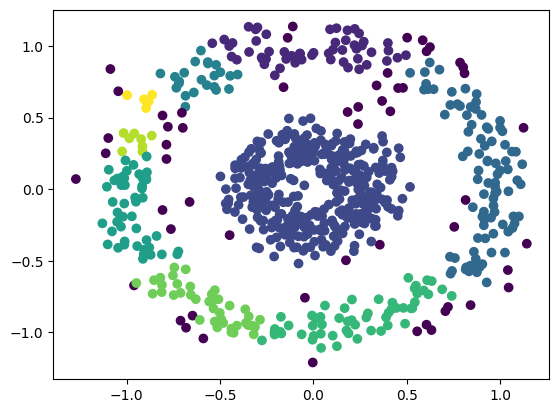

In [8]:
plt.scatter(X[:,0],X[:,1],c=dbcan.labels_)

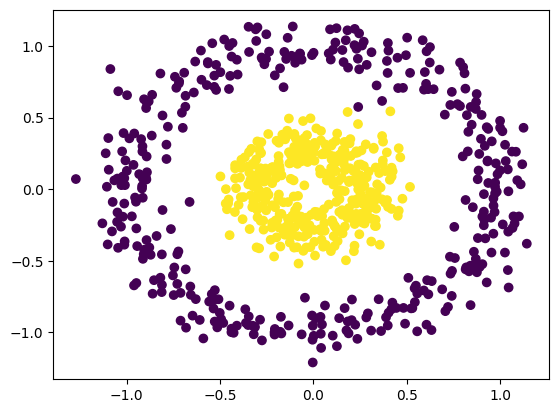

In [9]:
plt.scatter(X[:,0],X[:,1],c=y)

## Local Outlier Factor (LOF)

In [10]:
import numpy as np

# Using the same X, y from make_circles defined earlier
# Map y (0/1 class labels) to LOF convention: 1 = inlier, -1 = outlier
ground_truth = np.where(y == 1, 1, -1)

In [11]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = clf.fit_predict(X)
n_errors = (y_pred != ground_truth).sum() # type: ignore
X_scores = clf.negative_outlier_factor_

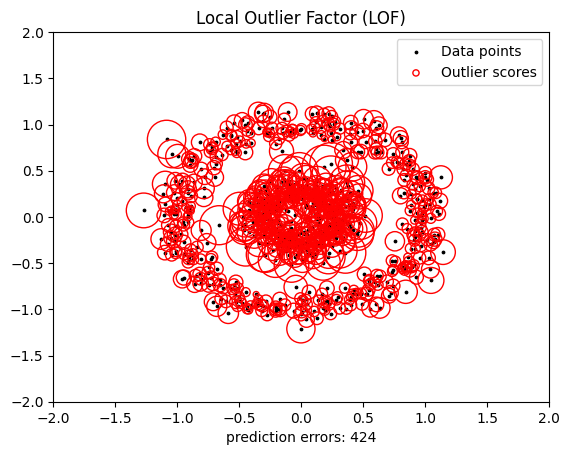

In [16]:
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerPathCollection

def update_legend_marker_size(handle, orig):
    "Customize size of the legend marker"
    handle.update_from(orig)
    handle.set_sizes([20])

plt.scatter(X[:, 0], X[:, 1], color="k", s=3.0, label="Data points")
# plot circles with radius proportional to the outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    s=1000 * radius,
    edgecolors="r",
    facecolors="none",
    label="Outlier scores",
)
plt.axis("tight")
plt.xlim((-2, 2))
plt.ylim((-2, 2))
plt.xlabel("prediction errors: %d" % (n_errors))
plt.legend(
    handler_map={scatter: HandlerPathCollection(update_func=update_legend_marker_size)}
)
plt.title("Local Outlier Factor (LOF)")
plt.show()